In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#  Data Loading and initial inspection


In [47]:
train = pd.read_csv('../Data/train.csv')
test = pd.read_csv('../Data/test.csv')

In [48]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [49]:
print(train.columns.tolist())

['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'PoolQC'

#  Explory Data Analysis (EDA)


In [50]:
# Data types check 
train.dtypes.value_counts()

object     43
int64      35
float64     3
Name: count, dtype: int64

In [51]:
# Missing values check
train.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [52]:
# Target variable 
train['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [53]:
# Missing values check columns
missing = train.isnull().sum()
missing[missing > 0]

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

In [54]:
# correlation of sale price with all other columns
corr = train.corr(numeric_only = True)

top_feature = corr['SalePrice'].sort_values(ascending=False).head(10)
print(top_feature)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64


Text(0.5, 1.0, 'SalePrice Distribution')

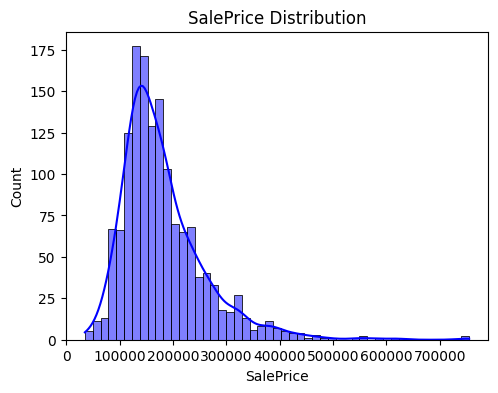

In [55]:
# SalePrice distribution plot (skewness check)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(train['SalePrice'], kde=True, color='blue')
plt.title('SalePrice Distribution')

In [59]:
# Apply log transformation to SalePrice to reduce skewness and data normalization
y_log = np.log1p(train['SalePrice'])

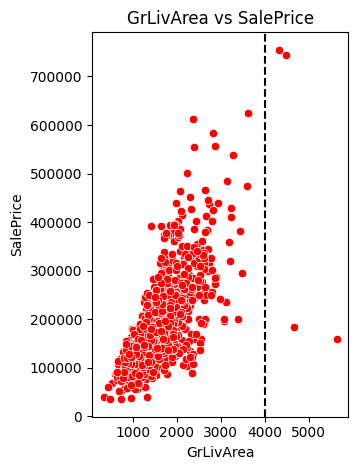

In [56]:
# Scatter plot for outliers check
plt.subplot(1, 2, 2)
sns.scatterplot(x=train['GrLivArea'], y=train['SalePrice'], color='red')
plt.axvline(x=4000, color='black', linestyle='--')
plt.title('GrLivArea vs SalePrice')

plt.tight_layout()
plt.show()

In [58]:
# GrLivArea outliers removal
outlier_indices = train.index[
    (train['GrLivArea'] > 4000) &
    (train['SalePrice'] < 300000)
]
train = train.drop(index=outlier_indices).reset_index(drop=True)

print("Update train shape:", train.shape)

Update train shape: (1458, 81)


In [11]:
# filling the missing numerical values

numeric_cols = train.select_dtypes(include = ['int64', 'float64']).columns
train[numeric_cols] = train[numeric_cols].fillna(train[numeric_cols].median())



In [12]:
# filling missing text (Categorical) values

categorical_cols = train.select_dtypes(include = ['object']).columns
train[categorical_cols] = train[categorical_cols].fillna('None')

In [13]:
# verifing the missing values
train.isnull().sum().sum()

0

In [14]:
# Text (categorical) variables encodinng / Text colmuns conver into numerical values

train = pd.get_dummies(train, drop_first=True)

train.shape

(1460, 262)

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error



In [60]:
# Seprate Input (X) and Output (Y) variables
X = train.drop('SalePrice', axis=1)
y = np.log1p(train['SalePrice'])

In [17]:
# Train and Validation data split (80% train and 20% validation)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
# Model train 
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [61]:
# Check model performance on (RMSE Error)

predictions_log = model.predict(X_val)
predictions = np.expm1(predictions_log)  # Convert log predictions back to original scale
y_val_actual = np.expm1(y_val)  # Convert log-transformed validation target back to original scale

rmse = np.sqrt(mean_squared_error(y_val_actual, predictions))
print(F"Validation RMSE: ${rmse:.2f}")


C:\Users\talha\AppData\Local\Temp\ipykernel_16948\977686552.py:4: RuntimeWarning: overflow encountered in expm1
  predictions = np.expm1(predictions_log)  # Convert log predictions back to original scale
C:\Users\talha\AppData\Roaming\Python\Python38\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: overflow encountered in expm1
  result = getattr(ufunc, method)(*inputs, **kwargs)


ValueError: Input contains infinity or a value too large for dtype('float64').

In [20]:
from sklearn.ensemble import RandomForestRegressor

In [21]:
# Make random forest model structure
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)


In [22]:
# Train model
rf_model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [24]:
# Set Validation predictions and check RMSE error
rf_pred = rf_model.predict(X_val)
rf_rmse = np.sqrt(mean_squared_error(y_val, rf_pred))

print(f"LinearRegression RMSE: ${rmse:.2f}")
print(f"RandomForestRegressor RMSE: ${rf_rmse:.2f}")

LinearRegression RMSE: $82993.51
RandomForestRegressor RMSE: $29275.22


In [26]:
from xgboost import XGBRegressor

In [27]:
# XGBoost model structure
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42)

In [28]:
# Model train 
xgb_model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [30]:
# Validation performnce check
xgb_preds = xgb_model.predict(X_val)
xgb_rsme = np.sqrt(mean_squared_error(y_val, xgb_preds))

print(f"LinearRegression RMSE: ${rmse:.2f}")
print(f"Random Forest RMSE: ${rf_rmse:.2f}")
print(f"XGBoost RMSE: ${xgb_rsme:.2f}")

LinearRegression RMSE: $82993.51
Random Forest RMSE: $29275.22
XGBoost RMSE: $26775.01


In [31]:
# test data fill Missing values

numeric_cols = test.select_dtypes(include = ['int64', 'float64']).columns
test[numeric_cols] = test[numeric_cols].fillna(test[numeric_cols].median())

categorical_cols = test.select_dtypes(include = ['object']).columns
test[categorical_cols] = test[categorical_cols].fillna('None')

In [33]:
# One-hot encoding for test data
test = pd.get_dummies(test, drop_first=True)

In [35]:
# Align the test data with the training data
X_train_final, test_final = X.align(test, join='left', axis=1, fill_value=0)

In [36]:
# XGBoost model fit on whole tarning data and predcict the test 
final_xgb = XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42)
final_xgb.fit(X_train_final, y)
final_preds = final_xgb.predict(test_final)


In [38]:
# Submission file creation
submission = pd.DataFrame({
    'id' : test['Id'],
    'salePrice' : final_preds
})

submission.to_csv('submission.csv', index=False)
print("Congratulations! Your final kaggle submission file has been created successfully.")

Congratulations! Your final kaggle submission file has been created successfully.


In [39]:
submission.head()

,id,salePrice
0,1461,128118.734375
1,1462,156903.437500
2,1463,182616.859375
3,1464,185168.515625
4,1465,203505.375000
